# confusion matrix
- 실제 정답인데 정답이라고 맞힌경우
- 실제 오답인데 오답이라고 맞힌경우
- 실제 오답인데 정답이라고 틀린경우
- 실제 정답인데 오답이라고 틀린경우

| 구분 | **예측 정답 (Positive)** | **예측 오답 (Negative)** |
| :--- | :---: | :---: |
| 실제 정답 (Positive) | TP | FN |
| 실제 오답 (Negative) | FP | TN |

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$
- PRECISION(정밀도) : 모델이 긍정이라고 예측한 것들중에서 실제 긍정인 비율 : 틀리지 않는것이 중요(스펨메일 분류)
$$\text{Precision} = \frac{TP}{TP + FP}$$
- Recall(재현율) : 실제 정답중에서 모델이 정답이라고 찾아낸 비율(암 진단)
$$\text{Recall} = \frac{TP}{TP + FN}$$
- F1-SCORE : 정밀도 재현율은 트레이드오프 관계가 있는경우가 많음 : 조화평균을 사용한다
$$F1 = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

($F_\beta$) : 재현율(Recall)을 정밀도(Precison) 보다 얼마나 더 중요하게 여기는지 나타내는 계수)
$$F_\beta = (1 + \beta^2) \times \frac{Precision \times Recall}{(\beta^2 \times Precision) + Recall}$$
- $beta$ = 2  : 재현율이 정밀도보다 2배 더 중요하게 본다( 놓치면 안되는 상황(잘못예측해도 어느정도 상쇄되는 상황) )
- $beta$ = 0.5  : 정밀도가 재현율보다 2배 더 중요하게 본다( 잘못예측하면 안되는 상황(놓쳐도 된다는 상황) )

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix,precision_score,recall_score,f1_score
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
import warnings 
warnings.filterwarnings('ignore')

In [8]:
y_true = np.array([0, 0, 0, 0, 0, 1, 1, 1, 1, 1])
# 모델이 1이라고 예측할 확률(0.0~1.0)
y_scores = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
# 임계값 설정
threshold = 0.5
# 예측 결과 계산
y_pred = (y_scores >= threshold).astype(int)
conf_matrix = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel().tolist()

conf_matrix, tn, fp, fn, tp

(array([[3, 2],
        [3, 2]], dtype=int64),
 3,
 2,
 3,
 2)

In [9]:
#정밀도
precisionscore = precision_score(y_true,y_pred)
print(precisionscore, 3/6)
# 재현율
recallscore = recall_score(y_true,y_pred)
print(recallscore, 2/5)

0.5 0.5
0.4 0.4


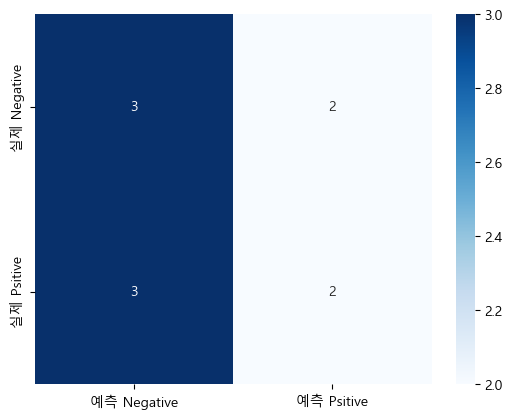

In [10]:
conf_matrix = confusion_matrix(y_true, y_pred)
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues',
            xticklabels= ['예측 Negative','예측 Psitive'],
            yticklabels= ['실제 Negative','실제 Psitive'],            
            )
plt.show()

In [11]:
y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.1, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])
threshold = 0.8  # 확실한 경우만 1로 보겠음... 
# 정밀도, 재현율
y_predict = (x_prob>=threshold).astype(int)
print( precision_score(y_true,y_predict),
        recall_score(y_true,y_predict)
)

threshold = 0.3  # 대략적으로 비슷하면 1로 보겠음...
# 정밀도, 재현율
y_predict = (x_prob>=threshold).astype(int)
print( precision_score(y_true,y_predict),
        recall_score(y_true,y_predict)
)

1.0 0.5
0.5714285714285714 1.0


실제정답 [0 0 0 1 1 0 0 1 1 0]
[0.4        0.44444444 0.57142857 0.66666667 0.8        1.
 1.         1.         1.         1.        ]
 [1.   1.   1.   1.   1.   1.   0.75 0.5  0.25 0.  ] 
 [0.1  0.2  0.3  0.35 0.4  0.6  0.7  0.8  0.9 ]


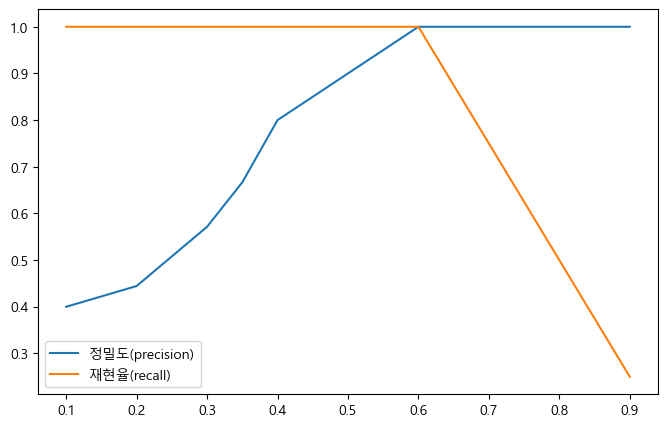

In [12]:
from sklearn.metrics import precision_recall_curve
precision , recall, threshold = precision_recall_curve(y_true,x_prob)
print('실제정답',y_true)
print(f'{precision}\n {recall} \n {threshold}')
plt.figure(figsize=(8,5))
plt.plot(threshold, precision[:-1],label='정밀도(precision)')
plt.plot(threshold, recall[:-1],label='재현율(recall)')
plt.legend()
plt.show()

- ROC (ROC Curve)  
    - 기준선을 바꿔가면서 진짜 정답을 맞추는 비율 TPR (Recall) 재현율  -y축
    
    $$\text{TPR} = \frac{TP}{TP + FN}$$
    
    - 오답을 정답이라고 판단한 비율 FPR    -x축

    $$FPR = \frac{FP}{FP + TN}$$

- AUC( Area Under the Curve)


[0.         0.16666667 0.16666667 0.66666667 1.        ] 
 [0.   0.25 1.   1.   1.  ] 
 [inf 0.9 0.6 0.3 0.2]
AUC(곡선아래 면적) 0.8542


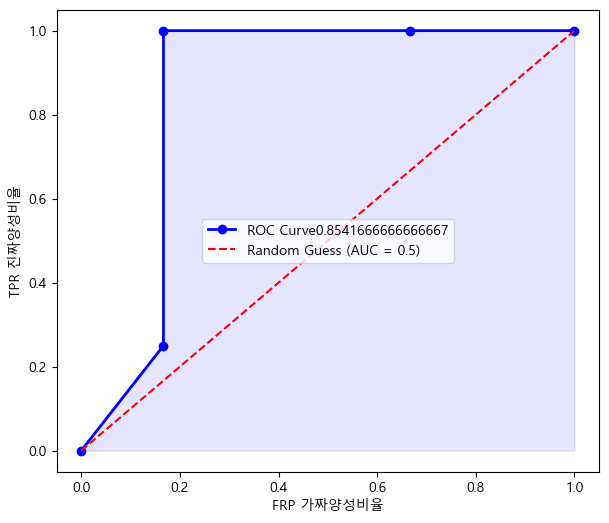

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

y_true = np.array([0, 0, 0, 1, 1, 0, 0, 1, 1, 0])
x_prob = np.array([0.9, 0.4, 0.35, 0.8, 0.9, 0.2, 0.3, 0.6, 0.7, 0.2])

roc_curve(y_true,x_prob)
fpr, tpr, threshold = roc_curve(y_true,x_prob)
print(fpr,'\n', tpr,'\n', threshold)
roc_acu = roc_auc_score(y_true,x_prob)
print(f'AUC(곡선아래 면적) {roc_acu:.4f}')

# ROC 곡선
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,color='blue',linewidth=2,marker='o', label=f'ROC Curve{roc_acu}') 
plt.plot([0,1],[0,1], color='red', linestyle='--', label='Random Guess (AUC = 0.5)')
plt.fill_between(fpr, tpr, color='blue', alpha=0.1) # 곡선아래 면적
plt.xlabel('FRP 가짜양성비율')
plt.ylabel('TPR 진짜양성비율')
plt.legend()
plt.show()

- 암진단처럼 재현율이 우선인 모델을 만들자
    - 1. 결과값에 threshold를 낮게 부여해서 recall 값을 올리는 threshold를 찾는 방법
    - 2. 학습할때 암환자를 놓치는 경우에 패널티를 강하게 부여(손실함수를 수정 BCEWithLogitLoss의 파라메터 조정)

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [35]:
from collections import Counter
data = load_breast_cancer()
X = data.data
y = 1 - data.target # 악성을 1, 양성(정상) 0
print(Counter(y))
# 데이터 분리 클래스비율 유지 8:2
x_train,x_test, y_train, y_test = train_test_split(X,y, stratify=y, random_state=42, test_size=0.2)
# 스케일링
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# 텐서로 변경
x_train_t = torch.FloatTensor(x_train)
y_train_t = torch.FloatTensor(y_train)
x_test_t = torch.FloatTensor(x_test)
y_test_t = torch.FloatTensor(y_test)

Counter({0: 357, 1: 212})


In [59]:
# 신경망 제작
# hidden (x_dim, 32)
# hidden (32, 16)
# hidden (16, 1)
# 활성화 함수 ReLu
class BreastModel(nn.Module):
    def __init__(self, x_dim):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(x_dim, 32),
            nn.ReLU(),

            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16,1)
        )
    def forward(self, x):
        return self.network(x)

def print_metrixs(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ps = precision_score(y_true, y_pred)
    rs = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f'confusion_matrix :  \n{cm}')
    print(f'precision_score : {ps:.4f}')
    print(f'****recall_score**** : {rs:.4f}')
    print(f'f1_score : {f1:.4f}')

In [74]:
torch.manual_seed(42)
model = BreastModel(x_train_t.shape[-1])
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(model.parameters(), lr=0.01)
epochs=100
for epoch in range(epochs):
    optimizer.zero_grad()
    y_predict = model(x_train_t).squeeze(1)
    loss = criterion(y_predict,y_train_t)
    loss.backward()
    optimizer.step()

with torch.no_grad():
    logits = model(x_test_t)    
    props = torch.sigmoid(logits).numpy()


threshold = 0.00001  # 0.00001 ~ 0.0001
preds_05 = (props >= threshold).astype(int)
print_metrixs(y_test,preds_05)

confusion_matrix :  
[[48 24]
 [ 0 42]]
precision_score : 0.6364
****recall_score**** : 1.0000
f1_score : 0.7778


In [75]:
# nn.BCEWithLogitsLoss  pos_weight 값이 높으면  1을 0으로 놓쳤을때 더 강한 패널티를 부여( 높은 손실점수)
torch.manual_seed(42)
# 암환자(1) 놓치는 것에 대해 정상(0) 보다 10배의 가중치(패널티)를 부여
weight_for_positive = torch.tensor([305.0])
model_weighted = BreastModel(x_train_t.shape[-1])
criterion_weighted = nn.BCEWithLogitsLoss(pos_weight=weight_for_positive)
optim_weighted = Adam(model_weighted.parameters(), lr=0.01)

epochs=100
for epoch in range(epochs):
    optim_weighted.zero_grad()
    y_predict = model_weighted(x_train_t).squeeze(1)
    loss = criterion_weighted(y_predict,y_train_t)
    loss.backward()
    optim_weighted.step()

with torch.no_grad():
    logits = model_weighted(x_test_t)    
    props = torch.sigmoid(logits).numpy()

threshold = 0.5
preds_05 = (props >= threshold).astype(int)
print_metrixs(y_test,preds_05)    

confusion_matrix :  
[[58 14]
 [ 0 42]]
precision_score : 0.7500
****recall_score**** : 1.0000
f1_score : 0.8571


[0.         0.         0.         0.01388889 0.01388889 0.19444444
 0.19444444 1.        ] 
 [0.         0.61904762 0.92857143 0.92857143 0.97619048 0.97619048
 1.         1.        ] 
 [       inf 1.         0.99889225 0.99680424 0.995093   0.5552137
 0.5052003  0.12722896]
AUC(곡선아래 면적) 0.9947


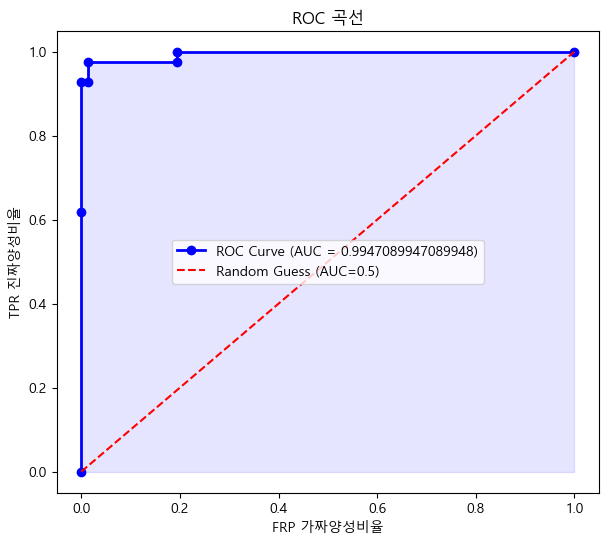

In [77]:
fpr,tpr,threshold = roc_curve(y_test,props)
print(fpr,'\n', tpr,'\n', threshold)
roc_acu = roc_auc_score(y_test,props)
print(f'AUC(곡선아래 면적) {roc_acu:.4f}')

# ROC 곡선
plt.figure(figsize=(7,6))
plt.plot(fpr,tpr,color='blue',linewidth=2,marker='o', label=f'ROC Curve (AUC = {roc_acu})') 
plt.plot([0,1],[0,1] ,color='red', linestyle='--' , label = 'Random Guess (AUC=0.5)')
plt.fill_between(fpr ,tpr, color='blue', alpha=0.1)  # 곡선아래 면적
plt.title('ROC 곡선')
plt.xlabel('FRP 가짜양성비율')
plt.ylabel('TPR 진짜양성비율')
plt.legend()
plt.show()